# Pytorch Workflow

In [228]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np



torch.__version__

'2.10.0+cpu'

# data preparing and loading


In [229]:
# create *Known* perameters

weight =0.7
bias=0.3

# create
start=0
end=1
step=0.02

X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

X

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [230]:
X[:10],y[:10],len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [231]:
# splitting data into training and testing


train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]

x_test,y_test=X[train_split:],y[train_split:]

len(X_train),len(y_train),len(x_test),len(y_test)



(40, 40, 10, 10)

In [232]:
# # in scikit_learn way

# from sklearn.model_selection import train_test_split

# x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
# len(X_train),len(y_train),len(x_test),len(y_test)



In [233]:
# Visualize the data

def plot_prediction(train_data=X_train,train_labels=y_train,test_data=x_test,test_labels=y_test,prediction=None):

  """
  Plot the training data and testing data and make some pridictions
  """

  plt.figure(figsize=(10,7))

  # training data
  plt.scatter(train_data,train_labels,c="b", s=4, label="Training Data")

  # testing data
  plt.scatter(test_data,test_labels,c="g", s=4, label="Testing Data")

  # prediction
  if prediction is not None:
    plt.scatter(test_data,prediction,c="r",s=4,label="predictions")

  #show legend(used to create a key that identifies different plotted elements (lines, points, bars, etc.) within a graph)
  plt.legend(prop={"size":14});









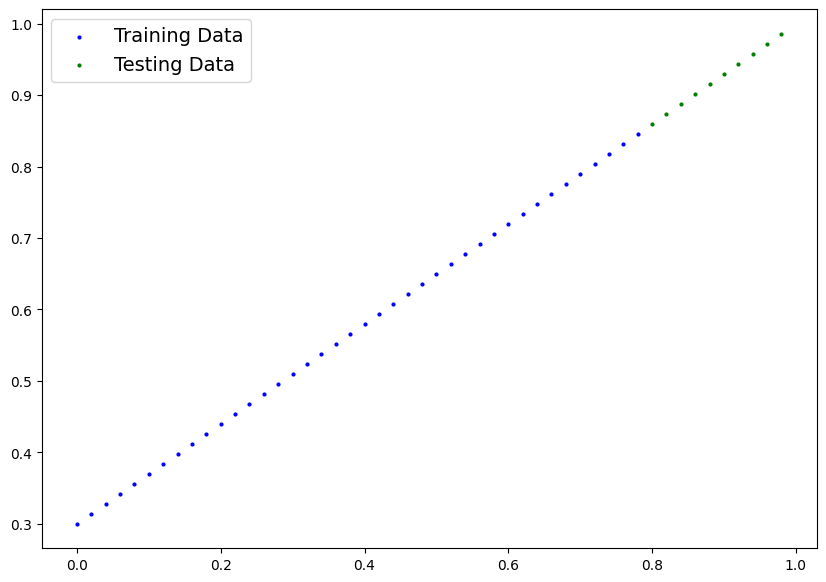

In [234]:
plot_prediction();

# Build Model

linear regression model

In [235]:
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

    self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

    # forword method to difine computation in the model
  def forward(self,x:torch.tensor)->torch.tensor:
      return self.weight*x+self.bias






In [236]:
# checking the contents of our pytorch model

# - create a rendom seed

torch.manual_seed(42)

# create an instance of the model(subclass of nn.modue)

model_0=LinearRegressionModel()

model_0


LinearRegressionModel()

In [237]:
# checkout parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [238]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [239]:
x_test,y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [240]:
### making predictions using 'torch.interface_mode()'

with torch.inference_mode():
  y_preds=model_0(x_test)

y_preds,y_test


(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

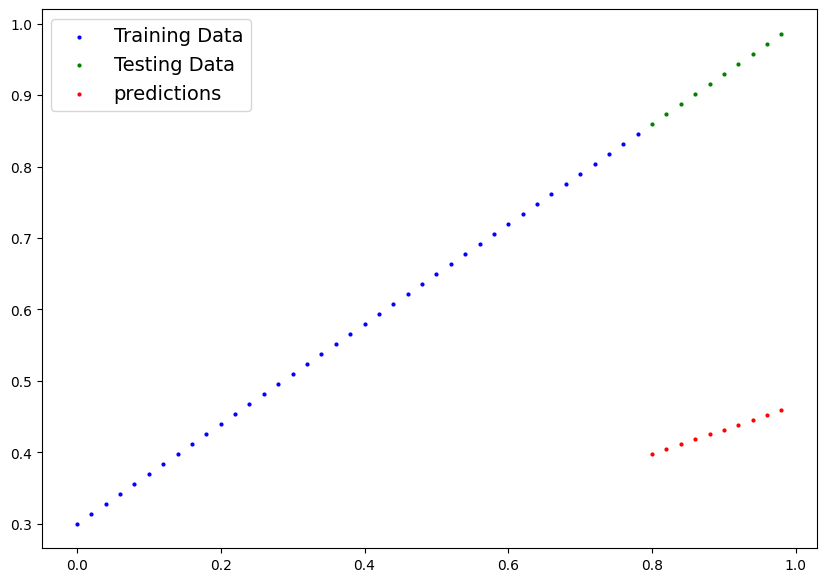

In [241]:
plot_prediction(prediction=y_preds)

In [242]:
# train Model

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [243]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [244]:
# setup loss function

loss_fn=nn.L1Loss()

# setup optimizer (Stochastic gradient descent)

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01) ##lr= learning rate (important hyper parameter)

optimizer


SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [245]:
## Build a training loop
torch.manual_seed(42)

epochs=200 # epochs is a loop throughthe data...(a hyperparameter becouse we set them)

# track
epoch_count=[]
test_loss_count=[]
loss_count=[]

### Training

for epoch in range(epochs):

  # set the model to training mode

  model_0.train() ## set all parameters that requires gradient to require gradients

  # 1. forward pass
  # we learn patterns on the training data to evauate our model on the test data
  y_pred= model_0(X_train)

  # 2. calculate loss
  loss=loss_fn(y_pred,y_train)
  # print(f"LOSS: {loss}")
  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. perfrom backprapagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. step the optimizer (perform gradient descent)
  optimizer.step() # by default how the optimizer changes will accumulate throyugh loop so.. we have to zero them above in step 3 for the next iteration of the loop


  # testing
  model_0.eval() # turns off different settings not neede for evaluation/tessting (dropout/batch more layers)
  with torch.inference_mode(): # turn off gradient tracking and couple of more thing behin the scenes
    # 1. farward pass
    test_pred=model_0(x_test)

    # 2. calculate loss
    test_loss=loss_fn(test_pred,y_test)

    # printout what's Happening
    if epoch%10==0:
      epoch_count.append(epoch)
      test_loss_count.append(loss) # .item is used to convert and grab only numbers
      loss_count.append(test_loss)
      print(f"Epoch: {epoch} | Loss : {loss} | Test_Loss: {test_loss} " )
      print(f"Model_parameters: {model_0.state_dict()}")


Epoch: 0 | Loss : 0.31288138031959534 | Test_Loss: 0.48106518387794495 
Model_parameters: OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss : 0.1976713240146637 | Test_Loss: 0.3463551998138428 
Model_parameters: OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss : 0.08908725529909134 | Test_Loss: 0.21729660034179688 
Model_parameters: OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss : 0.053148526698350906 | Test_Loss: 0.14464017748832703 
Model_parameters: OrderedDict({'weight': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss : 0.04543796554207802 | Test_Loss: 0.11360953003168106 
Model_parameters: OrderedDict({'weight': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss : 0.04167863354086876 | Test_Loss: 0.09919948130846024 
Model_parameters: OrderedDict({'weight': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss : 0.03818932920694351 | Test_Lo

In [246]:
print(f"Total Epochs: {epoch_count} | Total_loss:{loss_count} | Total_test_loss: {test_loss_count} ")


Total Epochs: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190] | Total_loss:[tensor(0.4811), tensor(0.3464), tensor(0.2173), tensor(0.1446), tensor(0.1136), tensor(0.0992), tensor(0.0889), tensor(0.0806), tensor(0.0723), tensor(0.0647), tensor(0.0565), tensor(0.0482), tensor(0.0406), tensor(0.0323), tensor(0.0241), tensor(0.0165), tensor(0.0082), tensor(0.0050), tensor(0.0050), tensor(0.0050)] | Total_test_loss: [tensor(0.3129, grad_fn=<MeanBackward0>), tensor(0.1977, grad_fn=<MeanBackward0>), tensor(0.0891, grad_fn=<MeanBackward0>), tensor(0.0531, grad_fn=<MeanBackward0>), tensor(0.0454, grad_fn=<MeanBackward0>), tensor(0.0417, grad_fn=<MeanBackward0>), tensor(0.0382, grad_fn=<MeanBackward0>), tensor(0.0348, grad_fn=<MeanBackward0>), tensor(0.0313, grad_fn=<MeanBackward0>), tensor(0.0279, grad_fn=<MeanBackward0>), tensor(0.0245, grad_fn=<MeanBackward0>), tensor(0.0210, grad_fn=<MeanBackward0>), tensor(0.0176, grad_fn=<MeanBackward0>), tensor(0.

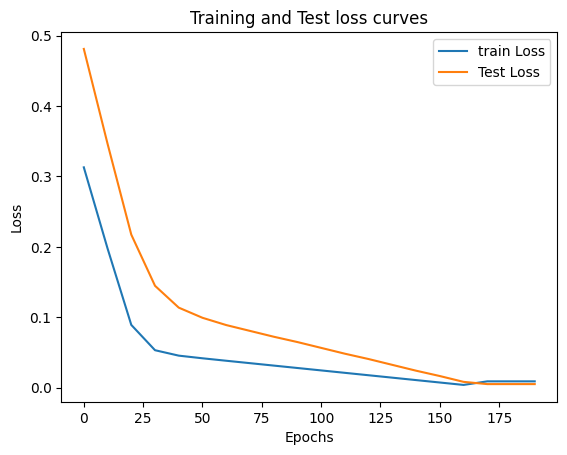

In [247]:
plt.plot(epoch_count,np.array(torch.tensor(test_loss_count).numpy()), label="train Loss")
plt.plot(epoch_count,loss_count,label="Test Loss")
plt.title("Training and Test loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [248]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [249]:
weight,bias

(0.7, 0.3)

In [250]:
with torch.inference_mode():   # torch.no_grad() - works same
  y_preds_new=model_0(x_test)



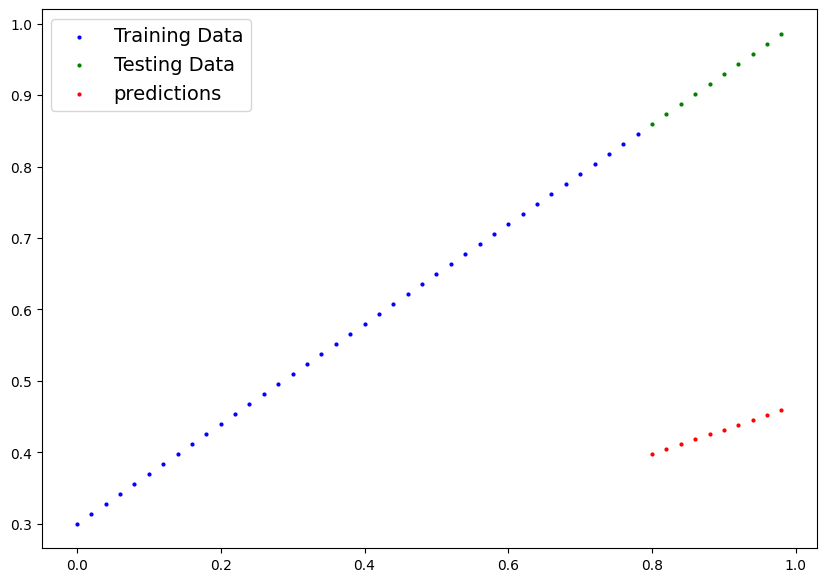

In [251]:
plot_prediction(prediction=y_preds)

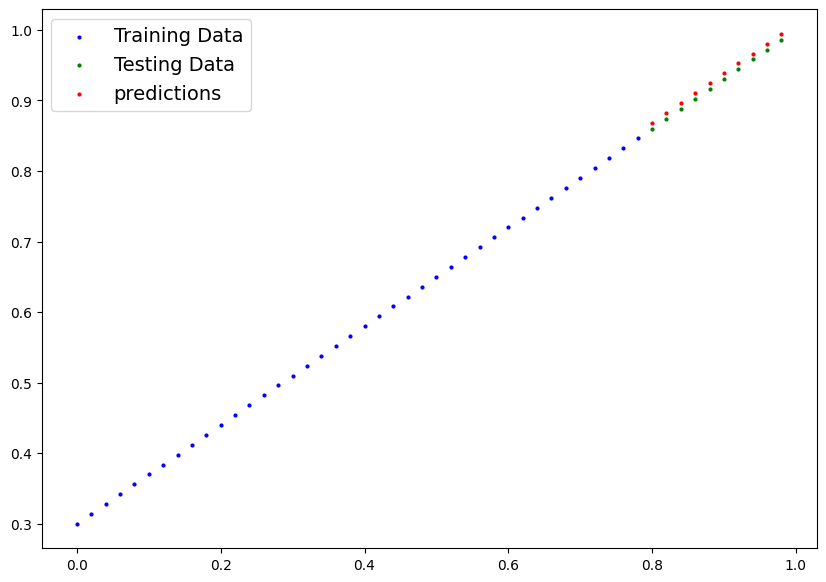

In [252]:
plot_prediction(prediction=y_preds_new)


# saving and loading the model

three main methods for saving and loading models

1. "torch.save()" - allows to save pytorch object in python's pickle format

2. "torch.load()" - allow to load a saved model(pytorch object)

3. "torch.nn.module.load_stat_dict()" - allows to load model's saved state dictionary


In [253]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [259]:
from pathlib import Path

# create model directory

model_path=Path("models")
model_path.mkdir(parents=True,exist_ok=True )


# create model save path

model_name="model_0_pytorch_workflow.pth"
model_save_path=model_path/model_name


# sace the model

torch.save(obj=model_0.state_dict(),f=model_save_path)

In [268]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [266]:
# to load in a saved satate_dict we to iniate a new instance of our model class

loaded_model_0=LinearRegressionModel()

# load the saved state_dict of odel_0 (this will update the new instance wih updated parameters)

loaded_model_0.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [267]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])